 # Projet analyse RFM avec Python, Bash et Git

# 4.3 Nettoyage et exploration en Python 

1. Import des bibliotheques

In [65]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

 2. chargement des donnees 

In [35]:

df = pd.read_csv('online_retail_II.csv')

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# 3. Exploration des proprietes de base

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      525461 non-null  str    
 1   StockCode    525461 non-null  str    
 2   Description  522533 non-null  str    
 3   Quantity     525461 non-null  int64  
 4   InvoiceDate  525461 non-null  str    
 5   Price        525461 non-null  float64
 6   Customer ID  417534 non-null  float64
 7   Country      525461 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


In [39]:
df.describe()

,Quantity,Price,Customer ID
count,525461.000000,525461.000000,417534.000000
mean,10.337667,4.688834,15360.645478
std,107.424110,146.126914,1680.811316
min,-9600.000000,-53594.360000,12346.000000
25%,1.000000,1.250000,13983.000000
50%,3.000000,2.100000,15311.000000
75%,10.000000,4.210000,16799.000000
max,19152.000000,25111.090000,18287.000000


In [41]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [43]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

In [49]:
# Nettoyage noms colonnes
df.columns = df.columns.str.strip()

df = df.rename(columns={
    'Customer ID': 'CustomerID',
    'Price': 'UnitPrice',
    'Invoice': 'InvoiceNo'
})

# Nettoyage
df = df.dropna(subset=['CustomerID'])
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [51]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue'],
      dtype='str')

4. Creation d'une colonne Revenue

In [55]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,5.90
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,7.50


6. Sauvegarde et commit

In [57]:
df.to_csv('cleaned_online_retail.csv', index=False)

# 4.4 Calcul des metriques RFM

In [59]:
df = pd.read_csv('cleaned_online_retail.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Date de référence
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Calcul RFM
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [61]:
# Scores
rfm['R'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Score'] = rfm[['R','F','M']].sum(axis=1)

In [63]:
def segment(row):
    if row['R'] >= 4 and row['F'] >= 4 and row['M'] >= 4:
        return 'Baleines'
    elif row['R'] >= 4 and row['F'] <= 2:
        return 'Nouveaux clients'
    elif row['R'] <= 2 and row['M'] >= 4:
        return 'Clients perdus'
    else:
        return 'Autres'

rfm['Segment'] = rfm.apply(segment, axis=1)

rfm['Segment'].value_counts()

Segment
Autres              2666
Baleines             926
Nouveaux clients     367
Clients perdus       353
Name: count, dtype: int64

In [69]:
rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Segment,,,
Autres,121.019130,2.383721,731.974045
Baleines,13.655508,11.676026,6187.627859
Clients perdus,143.274788,4.447592,2736.903238
Nouveaux clients,19.822888,1.297003,503.243134


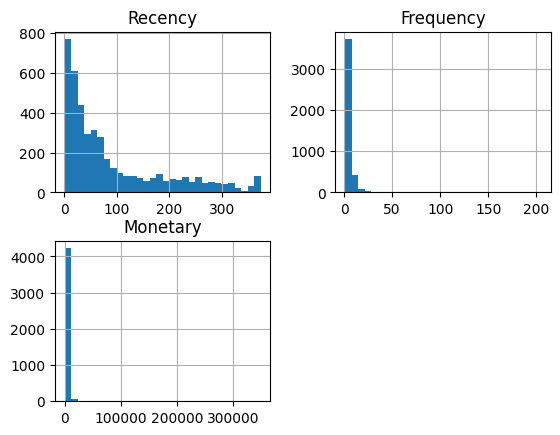

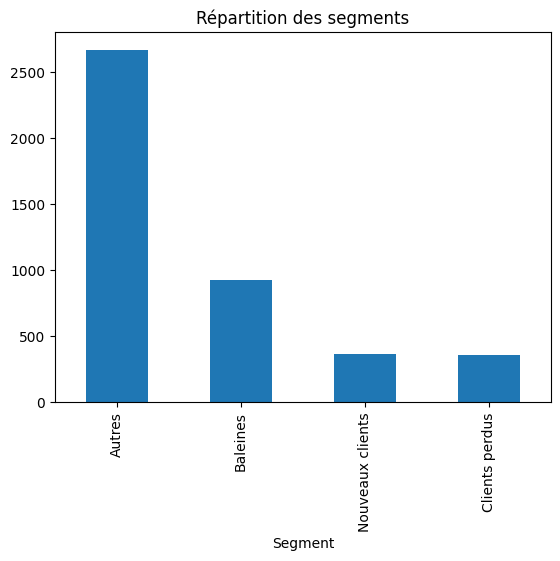

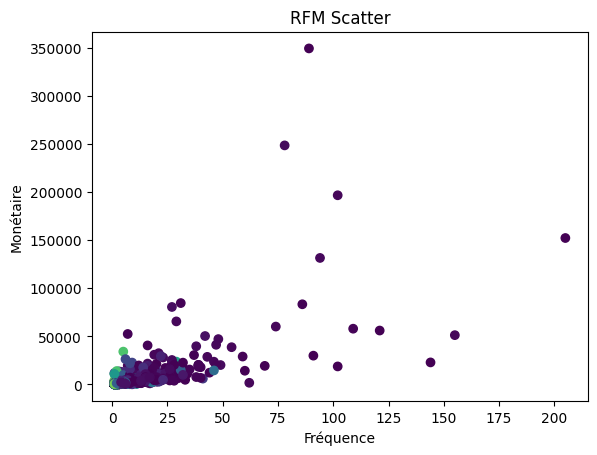

In [67]:
# Histogrammes
rfm[['Recency','Frequency','Monetary']].hist(bins=30)
plt.show()

# Barres segments
rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Répartition des segments")
plt.show()

# Scatter
plt.scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['Recency'])
plt.xlabel("Fréquence")
plt.ylabel("Monétaire")
plt.title("RFM Scatter")
plt.show()